In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import pickle # To load reference solution

import torch
from torch import nn

In [ ]:
# Setting devices
if torch.cuda.is_available():
  dev = "cuda:0"
else:
  dev = "cpu"
device = torch.device(dev)
print(device)

cpu


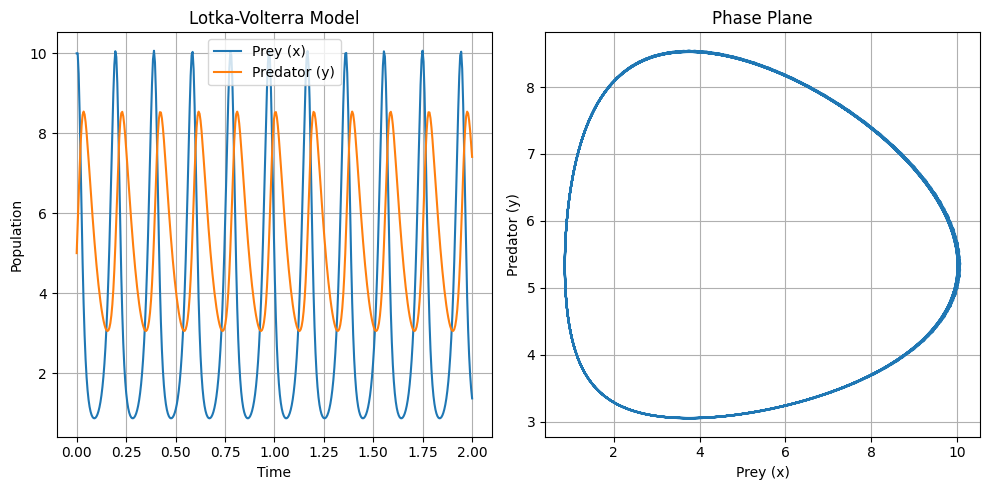

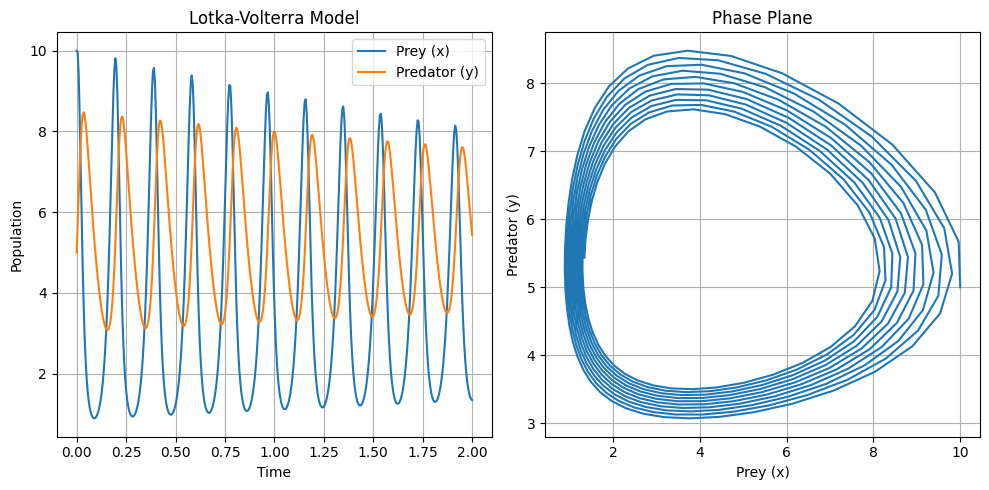

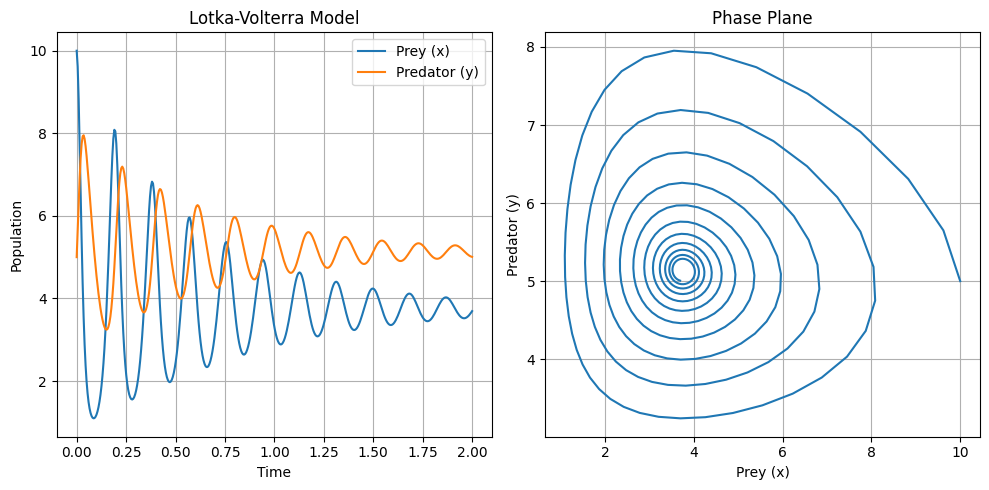

In [ ]:
with open("ref_data.pkl", "rb") as f:
    data = pickle.load(f)

alpha = data['alpha']   # Prey birth rate
beta  = data['beta']    # Predation rate
gamma = data['gamma']   # Predator death rate
delta = data['delta']   # Predator reproduction rate

K_vals = data['K_vals']
t      = data['t']
z0     = data['IC']

for i,K in enumerate(K_vals):

    sol = data[K]
    x = sol[:, 0]
    y = sol[:, 1]

    # Plot results
    plt.figure(figsize=(10, 5))

    # Time series
    plt.subplot(1, 2, 1)
    plt.plot(t, x, label='Prey (x)')
    plt.plot(t, y, label='Predator (y)')
    plt.xlabel('Time')
    plt.ylabel('Population')
    plt.title('Lotka-Volterra Model')
    plt.legend()
    plt.grid(True)

    # Phase plot
    plt.subplot(1, 2, 2)
    plt.plot(x, y)
    plt.xlabel('Prey (x)')
    plt.ylabel('Predator (y)')
    plt.title('Phase Plane')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
K = K_vals[2]
sol = data[K]
x = sol[:, 0]
y = sol[:, 1]
t = data['t']
x = x.astype(np.float32)
y = y.astype(np.float32)
t = t.astype(np.float32)

In [ ]:
x = torch.tensor(x).reshape(-1, 1)
y = torch.tensor(y).reshape(-1, 1)
t = torch.tensor(t).reshape(-1, 1)
t.shape

torch.Size([400, 1])

In [ ]:
x0 = data['IC'][0]
y0 = data['IC'][1]

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import display, clear_output

# Define MLP model
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim, depth, width, activation_fn):
        super(MLP, self).__init__()
        layers = []
        layers.append(nn.Linear(input_dim, width))
        layers.append(activation_fn())
        for l in range(1,depth-1):
            layers.append(nn.Linear(width, width))
            layers.append(activation_fn())
        layers.append(nn.Linear(width, output_dim))
        self.model = nn.Sequential(*layers)

    def forward(self, t):
        return self.model(t)

In [ ]:
def loss_fun(t, model):
    output = model(t)
    x = output[:, 0].reshape(-1, 1)
    y = output[:, 1].reshape(-1, 1)
    x_t = torch.autograd.grad(
            x, t,
            grad_outputs=torch.ones_like(t),
            create_graph=True)[0]
    y_t = torch.autograd.grad(
            y, t,
            grad_outputs=torch.ones_like(t),
            create_graph=True)[0]
    R_int1 = torch.mean(torch.square(x_t - alpha*x*(1-K*x) + beta*x*y))
    R_int2 = torch.mean(torch.square(y_t + gamma*y - delta*x*y))
    R_0  = torch.square(x[0] - x0) + torch.square(y[0] - y0)
    R_data = torch.mean(torch.square(x - y_test[:,0])) + torch.mean(torch.square(y - y_test[:,1]))

    return R_int1, R_int2, R_0, R_data

In [ ]:
# Training function
def train_model(model, x_train,x_test,y_test,num_epochs=100,lr= 0.001,lambda_b=1):
    plt.ion()  # Turn on interactive mode
    fig, ax = plt.subplots(1,6,figsize=(15,5))
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_int1_hist=np.zeros(num_epochs)
    loss_int2_hist=np.zeros(num_epochs)
    loss_0_hist=np.zeros(num_epochs)
    loss_d_hist=np.zeros(num_epochs)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=200, gamma=0.9)
    for epoch in range(1, num_epochs + 1):
        # zero the gradient buffers
        optimizer.zero_grad()

        # compute losses
        loss_int1, loss_int2 ,loss_0 , loss_d = loss_fun(x_train, model)
        loss = loss_int1 + loss_int2 + lambda_b*(loss_0  +  loss_d)

        # compute gradients of training loss
        loss.backward()

        # update weights
        optimizer.step()

        # save loss
        loss_int1_hist[epoch-1] = loss_int1.item()
        loss_int2_hist[epoch-1] = loss_int2.item()
        loss_0_hist[epoch-1] = loss_0.item()
        loss_d_hist[epoch-1] = loss_d.item()

        scheduler.step()

        # Plot every `plot_interval` epochs
        if epoch % 200 == 0:
            with torch.no_grad():
                y_pred = model(x_test).numpy()
            clear_output(wait=True)  # Clear previous output in Colab
            ax[0].clear()
            ax[0].plot(x_test.numpy(), y_test[:,0], label='True', color='blue')
            ax[0].plot(x_test.numpy(), y_pred[:, 0], label='Predicted', color='red')
            ax[0].set_xlabel('t')
            ax[0].set_ylabel('x')
            ax[0].legend()
            ax[0].set_title(f'Epoch {epoch}')

            ax[1].clear()
            ax[1].plot(x_test.numpy(), y_test[:,1], label='True', color='blue')
            ax[1].plot(x_test.numpy(), y_pred[:, 1], label='Predicted', color='red')
            ax[1].set_xlabel('t')
            ax[1].set_ylabel('y')
            ax[1].legend()
            ax[1].set_title(f'Epoch {epoch}')

            ax[2].clear()
            ax[2].semilogy(np.arange(1,epoch+1), loss_int1_hist[0:epoch], color='blue')
            ax[2].set_xlabel('Epoch')
            ax[2].set_ylabel(r'Loss int')

            ax[3].clear()
            ax[3].semilogy(np.arange(1,epoch+1), loss_int2_hist[0:epoch], color='blue')
            ax[3].set_xlabel('Epoch')
            ax[3].set_ylabel(r'Loss int')

            ax[4].clear()
            ax[4].semilogy(np.arange(1,epoch+1), loss_0_hist[0:epoch], color='blue')
            ax[4].set_xlabel('Epoch')
            ax[4].set_ylabel(r'Loss bnd')


            ax[5].clear()
            ax[5].semilogy(np.arange(1,epoch+1), loss_d_hist[0:epoch], color='blue')
            ax[5].set_xlabel('Epoch')
            ax[5].set_ylabel(r'Loss bnd')

            display(fig)  # Display updated plot

    print("Training Complete")
    plt.ioff()  # Turn off interactive mode
    plt.close(fig)
    return model, loss_int1_hist, loss_int2_hist, loss_0_hist, loss_d_hist

In [ ]:
class Sin(nn.Module):
    def forward(self, x):
        return torch.sin(x)


In [ ]:
import torch.nn.functional as F

class Hat(nn.Module):
    def __init__(self, a=0.0, b=0.5, c=1.0):
        super().__init__()
        assert a < b < c, "Require a < b < c"
        self.a = a
        self.b = b
        self.c = c

    def forward(self, x):
        return F.relu(x - self.a) - 2 * F.relu(x - self.b) + F.relu(x - self.c)

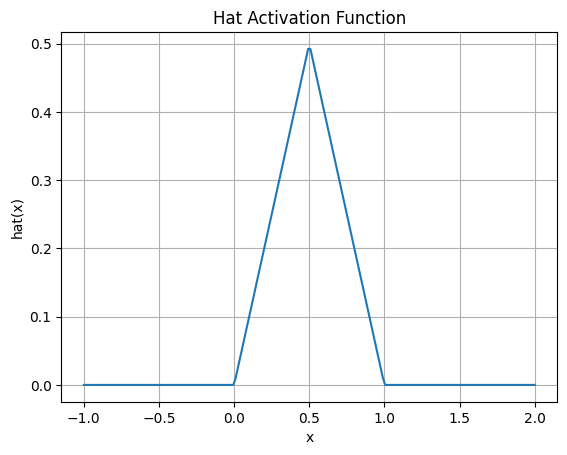

In [ ]:
if __name__ == "__main__":
    import matplotlib.pyplot as plt

    x = torch.linspace(-1, 2, steps=200)
    hat = Hat(a=0.0, b=0.5, c=1.0)
    y = hat(x)

    plt.plot(x.numpy(), y.detach().numpy())
    plt.title("Hat Activation Function")
    plt.xlabel("x")
    plt.ylabel("hat(x)")
    plt.grid(True)
    plt.show()

In [1]:
# Adjust as needed
input_dim     = 1
output_dim    = 2
depth         = 8
width         = 25
activation_fn = Hat
lr            = 0.01
num_epochs    = 16000
lambda_b      = 10.0 # Change as needed for greater peanlization of the boundary mismatch

#N              = 100
#x_train        = torch.linspace(0, 1, N, requires_grad=True).reshape(N,1)

x_train = t.clone().detach().requires_grad_(True)

#x_test         = torch.tensor(x).reshape(-1,1)
#y_test         = np.copy(u).reshape(-1,1)

x_test         = t
y_test         = torch.tensor(data[K])
# Initialize model
model = MLP(input_dim, output_dim, depth, width, activation_fn)

# Train model
model,loss_int1_hist, loss_int2_hist, loss_0_hist, loss_d_hist = train_model(model,x_train,x_test,y_test,num_epochs,lr,lambda_b)

NameError: name 'Hat' is not defined